In [1]:
pip install numpy torch torchvision matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 全局库导入
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# 设置随机种子保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

print("依赖库导入成功，环境准备完成")

依赖库导入成功，环境准备完成


In [3]:
# %% 2.1 卷积层输出尺寸与乘法次数计算
# 题目参数
in_channels = 3
in_height = 32
in_width = 32
out_channels = 16
kernel_size = 5
padding = 2
stride = 2

# 问题1：计算输出特征图尺寸
out_height = (in_height + 2 * padding - kernel_size) // stride + 1
out_width = (in_width + 2 * padding - kernel_size) // stride + 1
output_shape = (out_channels, out_height, out_width)

# 问题2：单个输出通道一个像素的点乘次数
# 每个卷积核与输入对应区域逐元素相乘，次数=输入通道数×卷积核高×卷积核宽
dot_product_count = in_channels * kernel_size * kernel_size

# 输出结果
print("="*50)
print("2.1 卷积层理论计算结果")
print("="*50)
print(f"1. 输出特征图尺寸: {output_shape[0]} × {output_shape[1]} × {output_shape[2]}")
print(f"2. 单个输出通道一个像素的点乘次数: {dot_product_count}次")

2.1 卷积层理论计算结果
1. 输出特征图尺寸: 16 × 16 × 16
2. 单个输出通道一个像素的点乘次数: 75次


In [4]:
# %% 2.2 手动实现二维最大池化（不使用框架API）
def max_pool2d_forward(x, kernel_size, stride=1, padding=0):
    """
    手动实现二维最大池化前向传播
    参数:
        x: 输入张量，形状为(N, C, H, W)
        kernel_size: 池化窗口大小 (kh, kw)
        stride: 步幅 (sh, sw)
        padding: 填充 (ph, pw)
    返回:
        out: 池化后的输出张量
    """
    # 统一参数格式
    if isinstance(kernel_size, int):
        kh, kw = kernel_size, kernel_size
    else:
        kh, kw = kernel_size
    
    if isinstance(stride, int):
        sh, sw = stride, stride
    else:
        sh, sw = stride
    
    if isinstance(padding, int):
        ph, pw = padding, padding
    else:
        ph, pw = padding
    
    N, C, H, W = x.shape
    
    # 计算输出尺寸
    out_h = (H + 2 * ph - kh) // sh + 1
    out_w = (W + 2 * pw - kw) // sw + 1
    
    # 对输入进行填充
    x_pad = torch.nn.functional.pad(x, (pw, pw, ph, ph), mode='constant', value=float('-inf'))
    
    # 初始化输出
    out = torch.zeros((N, C, out_h, out_w), dtype=x.dtype)
    
    # 遍历每个位置计算最大值
    for n in range(N):
        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    # 计算当前池化窗口的范围
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    
                    # 取窗口内的最大值
                    out[n, c, i, j] = torch.max(x_pad[n, c, h_start:h_end, w_start:w_end])
    
    return out

# 测试示例
print("="*50)
print("2.2 二维最大池化测试")
print("="*50)
# 创建测试输入 (1个样本，1个通道，4×4图像)
test_input = torch.tensor([[[[1, 2, 3, 4],
                             [5, 6, 7, 8],
                             [9, 10, 11, 12],
                             [13, 14, 15, 16]]]], dtype=torch.float32)

# 测试2×2池化，步幅2，无填充
output = max_pool2d_forward(test_input, kernel_size=2, stride=2, padding=0)
print("输入张量:")
print(test_input[0, 0])
print("\n2×2最大池化(步幅2)输出:")
print(output[0, 0])

2.2 二维最大池化测试
输入张量:
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

2×2最大池化(步幅2)输出:
tensor([[ 6.,  8.],
        [14., 16.]])


In [5]:
# %% 3.1 VGG网络参数量对比计算
# 题目参数：输入输出通道数均为C
C = 64  # 示例通道数，可替换为任意值

# 问题1：单个5×5卷积层参数量（不带偏置）
# 参数量=输入通道数×输出通道数×卷积核高×卷积核宽
conv5x5_params = C * C * 5 * 5

# 问题2：两个串联3×3卷积层总参数量（不带偏置，两层通道数均为C）
conv3x3_2layers_params = 2 * (C * C * 3 * 3)

# 输出结果
print("="*50)
print(f"3.1 VGG参数量对比 (通道数C={C})")
print("="*50)
print(f"1. 单个5×5卷积层参数量: {conv5x5_params:,}")
print(f"2. 两个串联3×3卷积层总参数量: {conv3x3_2layers_params:,}")
print(f"参数量减少比例: {(1 - conv3x3_2layers_params/conv5x5_params)*100:.1f}%")

3.1 VGG参数量对比 (通道数C=64)
1. 单个5×5卷积层参数量: 102,400
2. 两个串联3×3卷积层总参数量: 73,728
参数量减少比例: 28.0%


In [6]:
# %% 3.2 实现标准NiN块
class NiNBlock(nn.Module):
    """
    标准NiN块：普通卷积层 + 两个1×1卷积层，每层后接ReLU激活
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            # 第一个普通卷积层
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(inplace=True),
            # 第一个1×1卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            # 第二个1×1卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)

# 测试示例
print("="*50)
print("3.2 NiN块测试")
print("="*50)
# 创建NiN块：输入3通道，输出16通道，3×3卷积，步幅1，填充1
nin_block = NiNBlock(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
# 测试输入 (1个样本，3通道，32×32图像)
test_input = torch.randn(1, 3, 32, 32)
output = nin_block(test_input)
print(f"输入形状: {test_input.shape}")
print(f"输出形状: {output.shape}")
print(f"NiN块参数量: {sum(p.numel() for p in nin_block.parameters()):,}")

3.2 NiN块测试
输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 16, 32, 32])
NiN块参数量: 992


In [7]:
# %% 4.1 批量归一化层输出计算
# 题目参数
x = torch.tensor([2.0, 4.0, 6.0, 8.0])
gamma = 2.0
beta = 1.0
epsilon = 0.0

# 计算步骤
mean = torch.mean(x)
var = torch.var(x, unbiased=False)  # 批量归一化使用无偏方差
x_normalized = (x - mean) / torch.sqrt(var + epsilon)
y = gamma * x_normalized + beta

# 输出结果
print("="*50)
print("4.1 批量归一化计算结果")
print("="*50)
print(f"输入值: {x.numpy()}")
print(f"均值: {mean.item():.2f}")
print(f"方差: {var.item():.2f}")
print(f"标准化后值: {x_normalized.numpy().round(2)}")
print(f"最终输出y: {y.numpy().round(2)}")

4.1 批量归一化计算结果
输入值: [2. 4. 6. 8.]
均值: 5.00
方差: 5.00
标准化后值: [-1.34 -0.45  0.45  1.34]
最终输出y: [-1.68  0.11  1.89  3.68]


In [8]:
# %% 4.2 实现残差块(Residual Block)
class Residual(nn.Module):
    """
    标准残差块：两个3×3卷积层 + 批量归一化 + 残差连接
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        # 第一个3×3卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 第二个3×3卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 1×1卷积用于调整输入通道数和形状
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.conv3 = None
        # 激活函数
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # 主路径
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # 残差路径
        if self.conv3:
            x = self.conv3(x)
        # 相加后激活
        out += x
        return self.relu(out)

# 测试示例
print("="*50)
print("4.2 残差块测试")
print("="*50)
# 测试1：通道数不变，不使用1×1卷积
res_block1 = Residual(in_channels=3, out_channels=3, use_1x1conv=False)
test_input1 = torch.randn(1, 3, 32, 32)
output1 = res_block1(test_input1)
print(f"测试1 - 输入形状: {test_input1.shape}, 输出形状: {output1.shape}")

# 测试2：通道数变化，使用1×1卷积
res_block2 = Residual(in_channels=3, out_channels=16, use_1x1conv=True, stride=2)
test_input2 = torch.randn(1, 3, 32, 32)
output2 = res_block2(test_input2)
print(f"测试2 - 输入形状: {test_input2.shape}, 输出形状: {output2.shape}")

4.2 残差块测试
测试1 - 输入形状: torch.Size([1, 3, 32, 32]), 输出形状: torch.Size([1, 3, 32, 32])
测试2 - 输入形状: torch.Size([1, 3, 32, 32]), 输出形状: torch.Size([1, 16, 16, 16])


In [9]:
# %% 5.1 微调理论问题解答
print("="*50)
print("5.1 微调理论问题解答")
print("="*50)

print("\n问题1：为什么底层特征提取层设置较小学习率，顶层输出层设置较大学习率？")
print("-"*40)
print("""
1. 底层特征提取层学习到的是通用特征（边缘、纹理、颜色），这些特征在不同数据集上具有通用性
2. 这些特征已经在大型数据集上得到了充分训练，不需要大幅度修改
3. 顶层输出层是针对特定任务随机初始化的，需要快速学习任务相关的特征
4. 较小的学习率可以防止破坏已经学习到的通用特征，避免过拟合
""")

print("\n问题2：目标数据集很小且与源数据集相似时的微调策略？")
print("-"*40)
print("""
1. 冻结所有预训练层，只训练顶层输出层
2. 使用较小的批量大小和较低的学习率
3. 增加数据增强的强度，减少过拟合
4. 可以使用早停（Early Stopping）策略，防止训练过度
5. 可以尝试只微调最后几层卷积层，而不是整个网络
""")

5.1 微调理论问题解答

问题1：为什么底层特征提取层设置较小学习率，顶层输出层设置较大学习率？
----------------------------------------

1. 底层特征提取层学习到的是通用特征（边缘、纹理、颜色），这些特征在不同数据集上具有通用性
2. 这些特征已经在大型数据集上得到了充分训练，不需要大幅度修改
3. 顶层输出层是针对特定任务随机初始化的，需要快速学习任务相关的特征
4. 较小的学习率可以防止破坏已经学习到的通用特征，避免过拟合


问题2：目标数据集很小且与源数据集相似时的微调策略？
----------------------------------------

1. 冻结所有预训练层，只训练顶层输出层
2. 使用较小的批量大小和较低的学习率
3. 增加数据增强的强度，减少过拟合
4. 可以使用早停（Early Stopping）策略，防止训练过度
5. 可以尝试只微调最后几层卷积层，而不是整个网络



5.2 图像增广管道测试
图像增广管道已创建，包含以下操作：
1. RandomResizedCrop(224, scale=(0.08, 1.0))
2. RandomHorizontalFlip(p=0.5)
3. ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5)
4. ToTensor()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\457860358.py:43: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\457860358.py:43: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\457860358.py:43: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\457860358.py:43: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\457860358.py:43: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48952\45

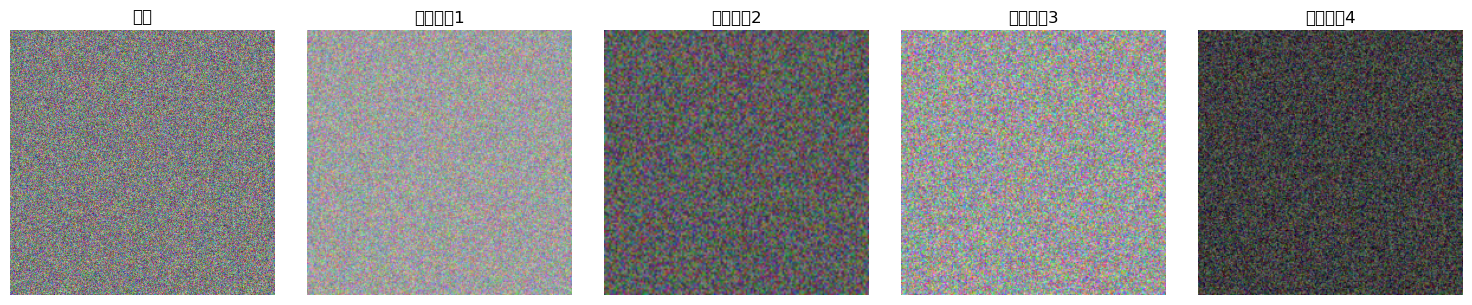


图像增广效果可视化完成


In [10]:
# %% 5.2 实现图像增广管道
# 创建图像增广管道
augmentation_pipeline = transforms.Compose([
    # 1. 随机裁剪并缩放到224×224
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    # 2. 50%概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. 随机改变亮度、对比度、饱和度
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    # 4. 转换为张量
    transforms.ToTensor()
])

# 测试示例（需要一张示例图片，替换为你的图片路径）
print("="*50)
print("5.2 图像增广管道测试")
print("="*50)
print("图像增广管道已创建，包含以下操作：")
print("1. RandomResizedCrop(224, scale=(0.08, 1.0))")
print("2. RandomHorizontalFlip(p=0.5)")
print("3. ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5)")
print("4. ToTensor()")

# 可选：可视化增广效果（需要matplotlib）
try:
    # 创建一张随机测试图像
    test_image = Image.fromarray((np.random.rand(512, 512, 3) * 255).astype(np.uint8))
    
    # 生成4张增广后的图像
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    axes[0].imshow(test_image)
    axes[0].set_title("原图")
    axes[0].axis('off')
    
    for i in range(1, 5):
        augmented_image = augmentation_pipeline(test_image)
        # 转换为PIL图像用于显示
        augmented_image = transforms.ToPILImage()(augmented_image)
        axes[i].imshow(augmented_image)
        axes[i].set_title(f"增广结果{i}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    print("\n图像增广效果可视化完成")
except Exception as e:
    print(f"\n可视化跳过：{e}")

In [11]:
# %% 6.1 边界框交并比(IoU)计算
def calculate_iou(boxA, boxB):
    """
    计算两个边界框的IoU
    参数:
        boxA: 真实框 [x1, y1, x2, y2]
        boxB: 预测框 [x1, y1, x2, y2]
    返回:
        iou: 交并比值
    """
    # 计算交集的坐标
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    
    # 计算交集面积
    intersection_area = max(0, x2 - x1) * max(0, y2 - y1)
    
    # 计算两个框的面积
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    # 计算并集面积
    union_area = boxA_area + boxB_area - intersection_area
    
    # 计算IoU
    iou = intersection_area / union_area if union_area > 0 else 0.0
    
    return iou, intersection_area, union_area

# 题目参数
boxA = [10, 10, 50, 50]  # 真实框
boxB = [30, 30, 70, 70]  # 预测框

iou, intersection, union = calculate_iou(boxA, boxB)

# 输出结果
print("="*50)
print("6.1 交并比(IoU)计算结果")
print("="*50)
print(f"真实框A: {boxA} (面积: {(boxA[2]-boxA[0])*(boxA[3]-boxA[1])})")
print(f"预测框B: {boxB} (面积: {(boxB[2]-boxB[0])*(boxB[3]-boxB[1])})")
print(f"交集面积: {intersection}")
print(f"并集面积: {union}")
print(f"IoU值: {iou:.4f}")

6.1 交并比(IoU)计算结果
真实框A: [10, 10, 50, 50] (面积: 1600)
预测框B: [30, 30, 70, 70] (面积: 1600)
交集面积: 400
并集面积: 2800
IoU值: 0.1429


In [12]:
# %% 6.2 实现标签平滑交叉熵损失
def label_smoothing_cross_entropy(logits, targets, epsilon=0.1):
    """
    计算标签平滑后的交叉熵损失
    参数:
        logits: 模型输出的未归一化得分，形状为(N, K)
        targets: 真实标签，形状为(N,)
        epsilon: 平滑因子
    返回:
        loss: 平均损失值
    """
    N, K = logits.shape
    
    # 计算softmax概率
    probs = torch.softmax(logits, dim=1)
    
    # 创建标签平滑后的目标概率
    smooth_targets = torch.zeros_like(probs)
    smooth_targets.scatter_(1, targets.unsqueeze(1), 1 - epsilon)
    smooth_targets += epsilon / (K - 1)
    
    # 计算交叉熵损失
    loss = -torch.sum(smooth_targets * torch.log(probs + 1e-10), dim=1)
    
    # 返回平均损失
    return torch.mean(loss)

# 测试示例
print("="*50)
print("6.2 标签平滑交叉熵损失测试")
print("="*50)
# 测试输入：3个样本，5分类问题
logits = torch.randn(3, 5)
targets = torch.tensor([0, 2, 4])  # 真实标签

# 计算损失
loss_with_smoothing = label_smoothing_cross_entropy(logits, targets, epsilon=0.1)
loss_without_smoothing = label_smoothing_cross_entropy(logits, targets, epsilon=0.0)

print(f"模型输出logits:\n{logits.numpy().round(2)}")
print(f"真实标签: {targets.numpy()}")
print(f"无标签平滑损失: {loss_without_smoothing.item():.4f}")
print(f"有标签平滑损失(epsilon=0.1): {loss_with_smoothing.item():.4f}")

6.2 标签平滑交叉熵损失测试
模型输出logits:
[[-0.16  0.07 -1.26  0.66  0.41]
 [-0.99 -1.22  0.1  -0.66  0.26]
 [-0.19  2.32  0.55 -0.38  0.98]]
真实标签: [0 2 4]
无标签平滑损失: 1.6213
有标签平滑损失(epsilon=0.1): 1.6961
